<a href="https://colab.research.google.com/github/LleilaA13/FDS25-26/blob/main/classnotes/FDS_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install torchviz
!pip install -q torchviz

In [ ]:
# Autograd-wrapped NumPy
import autograd.numpy as np
import numpy as onp
from autograd import grad, value_and_grad
from autograd.misc.flatten import flatten_func
import matplotlib.pyplot as plt

import plotly.graph_objects as go

# Plotting setup
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

Helper Functions:

In [ ]:
# @title
# Helper functions:

def plot_functions(w_values, y1, y2, color1='b', color2='r',
                   label1=r'$g(w)$', label2=r"$g'(w)$", title="Function and derivative"):
    plt.figure(figsize=(7, 5))
    plt.plot(w_values, y1, color1+'-', lw=2, label=label1)
    plt.plot(w_values, y2, color2+'-', lw=2, label=label2)
    plt.grid(alpha=0.3)
    plt.xlabel("w")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.show()


def plot_g_multi(surface_func, w1_range=(-3, 3), w2_range=(-3, 3), num_points=100):
    """
    Plot a 3D surface of a two-variable function using Plotly.

    Args:
        surface_func: function of two variables, e.g. g_multi(w1, w2)
        w1_range: tuple (min, max) for w1 axis
        w2_range: tuple (min, max) for w2 axis
        num_points: number of grid points per axis
    """
    # Create grid of points
    w1 = np.linspace(w1_range[0], w1_range[1], num_points)
    w2 = np.linspace(w2_range[0], w2_range[1], num_points)
    W1, W2 = np.meshgrid(w1, w2)
    Z = surface_func(W1, W2)

    # Build surface plot
    fig = go.Figure(data=[go.Surface(x=W1, y=W2, z=Z, colorscale="Viridis")])

    fig.update_layout(
        title=f"Surface plot of {surface_func.__name__}(w1, w2)",
        scene=dict(
            xaxis_title="w1",
            yaxis_title="w2",
            zaxis_title=f"{surface_func.__name__}(w1, w2)"
        ),
        autosize=True,
        width=700,
        height=500,
    )

    fig.show()


## A brief introduction to Autograd

We start with a brief example, where we define a target function $g(w) = tanh(w)$.

In this case, we can easily compute its derivative, $g'(w)= sech^2(w) = 1/cosh^2(x)$.

In [ ]:
def g(w):
  """
  g(w) defines the *hyperbolic tangent function*,
  whose derivative is sech^2(w), which can be
  expressed as 1/cosh^2(w).
  """
  return np.tanh(w)

def sech2(w):
  """
  Derivative of g(w): sech^2(w)
  """
  return 1/(np.cosh(w)**2)

If we plot the function and its (known) derivative, we obtain the following:

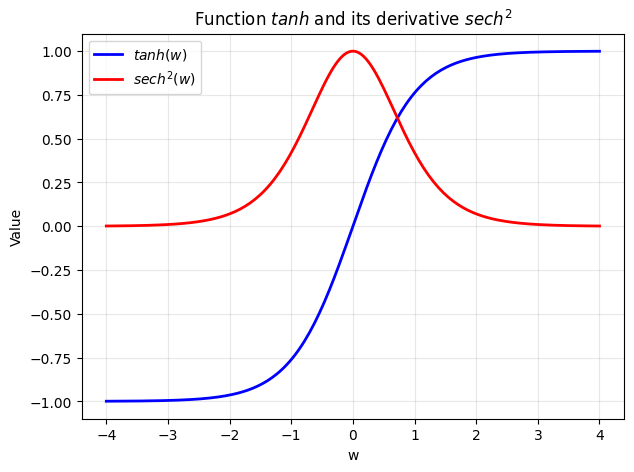

In [ ]:
w_values = np.linspace(-4, 4, 200)

g_values = [g(w) for w in w_values]
sech2_values =  [sech2(w) for w in w_values]

plot_functions(w_values, g_values, sech2_values, color1='b', color2='r',
               label1=r'$tanh(w)$', label2=r"$sech^2(w)$",
               title="Function $tanh$ and its derivative $sech^2$")

However, this is not always the case. We might work with arbitrarily complex functions, for which there is no know derivative...

This is why we introduce Autograd:

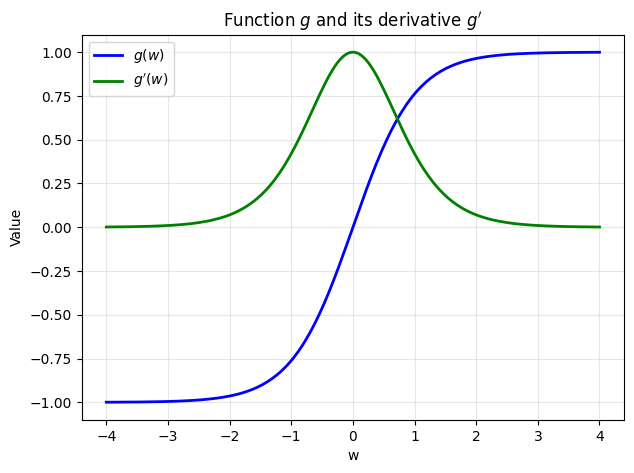

In [ ]:
# Autograd gradient, in this case dg/dw:
dgdw = grad(g)

g_values = [g(w) for w in w_values]
autograd_values = [dgdw(w) for w in w_values]

plot_functions(w_values, g_values, autograd_values, color1='b', color2='g',
               label1=r'$g(w)$', label2=r"$g'(w)$",
               title="Function $g$ and its derivative $g'$")

To simplify our work, Autograd provides the function `value_and_grad` which, given a scalar input `w`, returns both the value `g(w)` and its derivative `g'(w)`.


In [ ]:
g_and_grad_for_tanh = value_and_grad(g)

w = 1.0
g_val, grad_val = g_and_grad_for_tanh(w)

print("Autograd:\n-----------------")
print(f"At w = {w}:\n - g(w) = {round(g_val, 2)},\n - g'(w) = {round(grad_val, 2)}")

###################################################
print(f"\nAnalytical check:\n-----------------")

print(f"At w = {w}")
tanh_value = round(g(w), 2)
sec2_value = round(sech2(w), 2)
print(f" - g(w) = {tanh_value},\n - g'(w) = {round(1 - np.tanh(w)**2, 2)}")

Autograd:
-----------------
At w = 1.0:
 - g(w) = 0.76,
 - g'(w) = 0.42

Analytical check:
-----------------
At w = 1.0
 - g(w) = 0.76,
 - g'(w) = 0.42


### Use Case: Taylor's Theorem

The **first-order Taylor expansion** is a way to approximate a *nonlinear* function $f(x)$ by a *linear* function near a chosen point $x_0$.

The formula is:
$$f(x) \approx f(x_0) + f'(x_0)\,(x - x_0)$$

where
- $x_0$ is the "expansion point"
- $f(x_0)$ is the value of the function at the expansion point
- $f'(x_0)$ is the derivative (slope) of the function at the expansion point
- The approximation is simply the **tangent line** to the curve of $f$ at $x_0$

**Why is it useful?**
- If we zoom in at $x_0$, the tangent line is almost indistinguishable from the function itself.  
- It provides a simple linear model of a potentially complex function.  
- This idea is central to numerical analysis, optimization, and gradient-based methods in machine learning.

**Key intuition:**  
A complicated nonlinear function can be locally approximated by a straight line, as long as we stay close to the expansion point.

---
For more details, please refer to [here](https://en.wikipedia.org/wiki/Taylor%27s_theorem).

In [ ]:
def first_order_taylor(w0, w):
    """
    First-order Taylor expansion of g(w) around point w0.
    Formula: g(w) ≈ g(w0) + g'(w0) * (w - w0)
    """
    return g(w0) + dgdw(w0) * (w - w0)

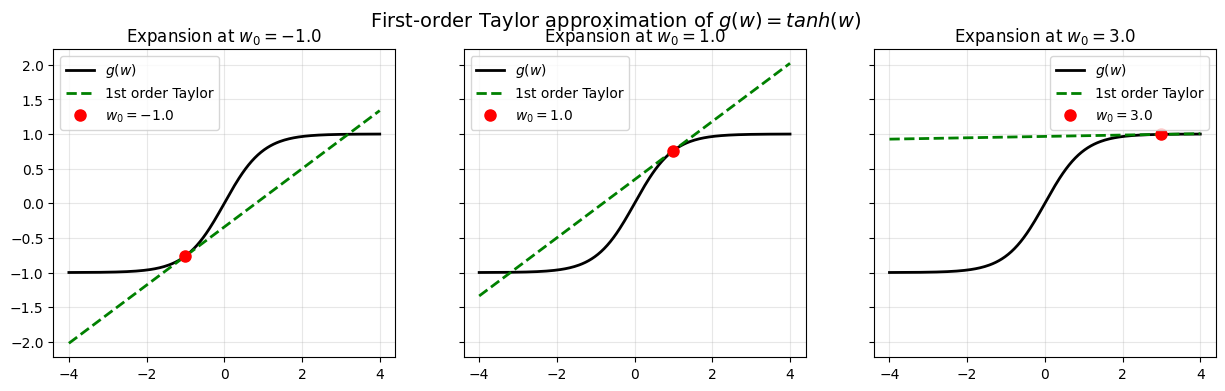

In [ ]:
# @title
# Grid of w values
w_values = np.linspace(-4, 4, 200)
g_vals = [g(w) for w in w_values]

# Expansion points
w0_list = [-1.0, 1.0, 3.0]

# Create side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, w0 in zip(axes, w0_list):
    t1_vals = [first_order_taylor(w0, w) for w in w_values]
    ax.plot(w_values, g_vals, 'k-', lw=2, label="$g(w)$")
    ax.plot(w_values, t1_vals, 'g--', lw=2, label="1st order Taylor")
    ax.plot(w0, g(w0), 'ro', ms=8, label=f"$w_0={w0}$")
    ax.set_title(f"Expansion at $w_0={w0}$")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("First-order Taylor approximation of $g(w)=tanh(w)$", fontsize=14)
plt.show()

### Partial derivatives and gradients in Multiple Dimensions

When a function depends on more than one variable, for example  

$$g(w_1, w_2) = \tanh(w_1 \cdot w_2)$$

we can no longer talk about a single derivative.  
Instead, we compute **partial derivatives**, which measure how the function changes when only one variable changes, keeping the others fixed:

$$\frac{\partial g}{\partial w_1}(w_1, w_2), \quad
\frac{\partial g}{\partial w_2}(w_1, w_2)$$


Collecting all partial derivatives gives the **gradient vector**:

$$\nabla g(w_1, w_2) =
\begin{bmatrix}
\frac{\partial g}{\partial w_1} \\
\frac{\partial g}{\partial w_2}
\end{bmatrix}$$

- Each component of the gradient corresponds to the slope of the surface along one axis.  
- The gradient as a whole points in the direction of **steepest ascent** of the function.  
- This concept generalizes to functions of many variables and is central in optimization and machine learning.


Let's define a very easy bi-dimensional counterpart of the previous $tanh$ function:

In [ ]:
def g_multi(w1, w2):
    """
    Multivariable function g(w1, w2).

    Defined as:
        g(w1, w2) = tanh(w1 * w2)

    - Input: two scalars (w1, w2)
    - Output: a scalar value

    This function depends on both variables, so we can study
    its partial derivatives with respect to w1 and w2 separately.
    """
    return np.tanh(w1 * w2)

In [ ]:
plot_g_multi(g_multi, w1_range=(-3,3), w2_range=(-3,3), num_points=100)


How do we compute partial derivatives here?
Autograd can help us:



In [ ]:
partial_w1 = grad(g_multi, 0)
partial_w2 = grad(g_multi, 1)
print("Partial derivatives computed successfully!")

Partial derivatives computed successfully!


- `grad(g_multi, 0)` creates a new function that computes  
  $$\frac{\partial}{\partial w_1} g(w_1, w_2)$$  
- `grad(g_multi, 1)` creates a new function that computes  
  $$\frac{\partial}{\partial w_2} g(w_1, w_2)$$  
   

Yes, easy as that!

Let's try to visualize these derivatives:

In [ ]:
# --- Grid (use plain numpy for arrays) ---
w1_range = onp.linspace(-2, 2, 60)
w2_range = onp.linspace(-2, 2, 60)
W1, W2 = onp.meshgrid(w1_range, w2_range)

# --- Evaluate function on the grid (vectorized with plain numpy) ---
G = onp.tanh(W1 * W2)

# --- Fill partial derivatives with loops as requested ---
dG_dW1 = onp.zeros_like(G)
dG_dW2 = onp.zeros_like(G)

# Note: pass scalars to partial_w1/partial_w2
for i in range(len(w1_range)):
    for j in range(len(w2_range)):
        dG_dW1[j, i] = partial_w1(w1_range[i], w2_range[j])
        dG_dW2[j, i] = partial_w2(w1_range[i], w2_range[j])

In [ ]:
# @title
import plotly.graph_objects as go
import plotly.subplots as sp

# Create subplot layout with 1 row and 3 columns
fig = sp.make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        "g(w1, w2) = tanh(w1·w2)",
        "∂g/∂w1",
        "∂g/∂w2"
    ),
    specs=[[{"type": "surface"}, {"type": "surface"}, {"type": "surface"}]]
)

# Original function
fig.add_trace(
    go.Surface(x=W1, y=W2, z=G, colorscale="Viridis"),
    row=1, col=1
)

# Partial derivative wrt w1
fig.add_trace(
    go.Surface(x=W1, y=W2, z=dG_dW1, colorscale="Plasma"),
    row=1, col=2
)

# Partial derivative wrt w2
fig.add_trace(
    go.Surface(x=W1, y=W2, z=dG_dW2, colorscale="Inferno"),
    row=1, col=3
)

# Layout adjustments
fig.update_layout(
    title_text="Function and Partial Derivatives (Interactive Surfaces)",
    width=1400,
    height=500,
    scene=dict(
        xaxis_title="w1",
        yaxis_title="w2",
        zaxis_title="Value"
    )
)

fig.show()

#### Computing the full gradient with Autograd

Until now, we are computing derivates separately. We need to manually specifcy for which variable we want to differentiate (0, 1, ...). This is not so useful for situations in which we have millions if not billions of variables.\

Instead of calculating each partial derivative separately, Autograd allows us to obtain the **full gradient** of a multivariable function in one step. By passing a *tuple* of argument indices to `grad`, we get a function that returns all partial derivatives together, i.e. the gradient vector:

$$
\nabla g(w_1, w_2) =
\left(
\frac{\partial g}{\partial w_1}, \;
\frac{\partial g}{\partial w_2}
\right)
$$

This is useful when we want to evaluate how the function changes in every direction at once.


In [ ]:
# Ask Autograd to compute gradient wrt both arguments (w1 and w2)
full_gradient = grad(g_multi, (0, 1))

# Choose a test point in the (w1, w2) plane
w1_test, w2_test = 1.5, 0.8

# Evaluate the gradient at the chosen point
grad_w1, grad_w2 = full_gradient(w1_test, w2_test)

# Print results
print(f"At point (w1={w1_test}, w2={w2_test}):")
print(f"∂g/∂w1 = {grad_w1:.4f}")
print(f"∂g/∂w2 = {grad_w2:.4f}")

At point (w1=1.5, w2=0.8):
∂g/∂w1 = 0.2440
∂g/∂w2 = 0.4575


### Vectorized Gradient: computing gradients with vector input

Instead of defining the function with separate scalar inputs, we can define it as a function of a **vector**.  
Autograd then returns the gradient directly as a vector of partial derivatives, one for each component of the input.  

This approach is more compact and scales better when dealing with functions of many variables.


In [ ]:
# Vector input version
def g_vector(w):
  """
  Multivariable function g(w) with vector input.

  Defined as:
      g(w) = tanh(w[0] * w[1])

  - Input: one vector/array w = [w1, w2]
  - Output: a scalar value

  Difference from g_multi: unlike g_multi(w1, w2) which takes two separate
  scalar arguments, g_vector(w) takes a single vector argument and
  extracts its components.
  """
  return np.tanh(w[0] * w[1])

# Ask Autograd to compute the gradient wrt the entire vector
grad_vector = grad(g_vector)

# Test point as a NumPy array
w_test = np.array([1.5, 0.8]) # --> Now you see the difference!

# Evaluate the gradient at the test point (returns a vector of partials)
gradient = grad_vector(w_test)

# Print results
print("\nUsing vector input method:")
print(f"At point {w_test}: Gradient = {gradient}")

# Alternatively you can assign entries to individual variables:
print(f"\nExplicitly:\n - ∂g/∂w1 = {gradient[0]:.4f},\n - ∂g/∂w2 = {gradient[1]:.4f}")


Using vector input method:
At point [1.5 0.8]: Gradient = [0.244016   0.45752999]

Explicitly:
 - ∂g/∂w1 = 0.2440,
 - ∂g/∂w2 = 0.4575


### Ways to compute gradients with Autograd

| Method | Function definition | Input type | Output type | Use case |
|--------|---------------------|------------|-------------|----------|
| `grad(g_multi, (0,1))` | `g_multi(w1, w2)` | Two **scalars** | Tuple `(∂g/∂w1, ∂g/∂w2)` | Gradient at a single point <br> with multiple scalar arguments |
| `grad(g_vector)` | `g_vector(w)` with `w = [w1, w2]` | One **vector/array** | Array `[∂g/∂w1, ∂g/∂w2]` | Gradient at a single point <br> with vector input <br> (scales well to higher dimensions) |
| `elementwise_grad(g_multi, i)` | `g_multi(w1, w2)` | **Arrays/Grids** `W1, W2` | Array of same shape as input | Computes a partial derivative <br> over an entire grid of values <br> (vectorized) |

**Key idea:**  
- `grad` → works at a single point (scalar or vector).  
- `elementwise_grad` → works elementwise on arrays, ideal for plotting gradient fields.


In [ ]:
from autograd import elementwise_grad

# Vectorize the gradient computation using elementwise_grad
partial_w1_vec = elementwise_grad(g_multi, 0)
partial_w2_vec = elementwise_grad(g_multi, 1)

grad_W1_vec = partial_w1_vec(W1, W2)
grad_W2_vec = partial_w2_vec(W1, W2)

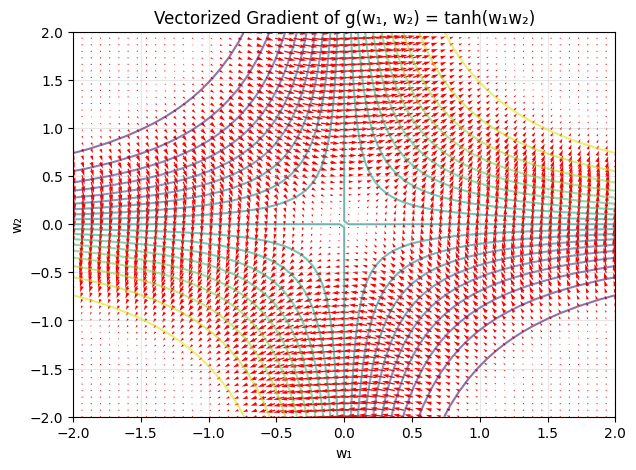

In [ ]:
# @title
# Plot the gradient as a quiver plot
plt.figure(figsize=(7, 5))
plt.quiver(W1, W2, grad_W1_vec, grad_W2_vec, color='r', scale=50)
plt.contour(W1, W2, G, levels=20, cmap='viridis', alpha=0.6) # Add contour lines of the function for context
plt.title("Vectorized Gradient of g(w₁, w₂) = tanh(w₁w₂)")
plt.xlabel("w₁")
plt.ylabel("w₂")
plt.grid(alpha=0.3)
plt.show()

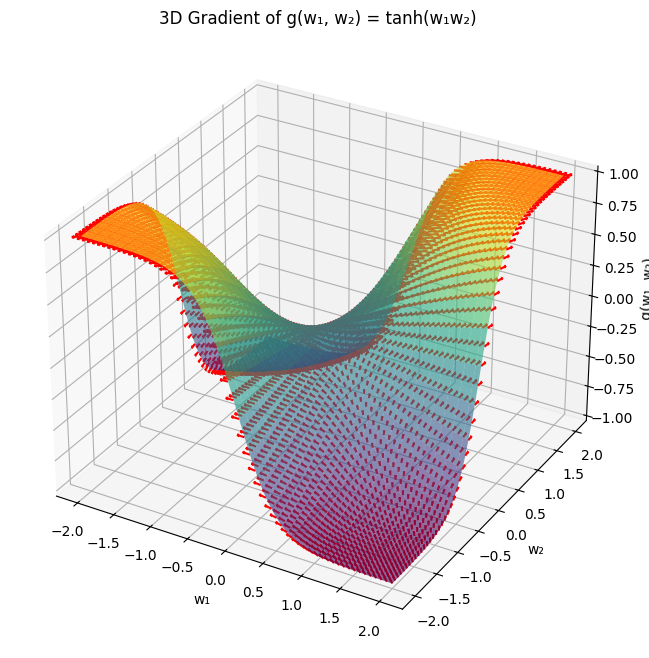

In [ ]:
# @title
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the gradient vectors
# We need to flatten the arrays for quiver
ax.quiver(W1.flatten(), W2.flatten(), G.flatten(),
          grad_W1_vec.flatten(), grad_W2_vec.flatten(), np.zeros_like(G).flatten(),
          length=0.1, color='r', normalize=True)

# Plot the surface of the function for context
ax.plot_surface(W1, W2, G, cmap='viridis', alpha=0.6)


ax.set_title("3D Gradient of g(w₁, w₂) = tanh(w₁w₂)")
ax.set_xlabel("w₁")
ax.set_ylabel("w₂")
ax.set_zlabel("g(w₁, w₂)")

plt.show()

# Big Spoiler: Autograd vs PyTorch

**Autograd**  
Autograd is a lightweight Python package developed at the *Harvard Intelligent Probabilistic Systems Group (HIPS)* around 2015.  
It extends NumPy with automatic differentiation: every NumPy operation is traced so that gradients can be computed automatically.  
It is simple and educational, mainly used for teaching and prototyping.

**PyTorch**  
PyTorch is an open-source deep learning framework originally developed by Meta AI (Facebook) and now maintained under the PyTorch Foundation, part of the Linux Foundation.  
It is one of the most widely used machine learning libraries, alongside TensorFlow, and supports computer vision, natural language processing, and general deep learning research.  
PyTorch builds on the older *Torch* and *Torch7* projects, but introduces a Python-first API and a powerful **Autograd engine** for automatic differentiation.  
It uses tensors (similar to NumPy arrays, but GPU-accelerated) as its core datatype, and supports large-scale training on CPUs and GPUs.  
Many popular frameworks and tools, such as Hugging Face Transformers and Tesla Autopilot, are built on top of PyTorch.


You should thank Pytorch for basically every AI tool out there :)
---

If you are curios, check [this](https://en.wikipedia.org/wiki/Graphics_processing_unit#History) out.

In [ ]:
import torch

# Define a tensor with requires_grad=True to track gradients
x = torch.tensor(2.0, requires_grad=True)

# Define a simple function
y = x**2 + 3*x + 1

# Compute the gradient of y with respect to x
y.backward()

# Access the gradient
gradient_x = x.grad

print(f"For y = x^2 + 3x + 1")
print(f"At x = {x.item()}, y = {y.item()}")
print(f"The gradient of y with respect to x is: {gradient_x.item()}")

# Analytical check: dy/dx = 2x + 3
# At x = 2.0, dy/dx = 2(2.0) + 3 = 4.0 + 3 = 7.0
print(f"\nAnalytical check: 2 * {x.item()} + 3 = {2 * x.item() + 3}")

For y = x^2 + 3x + 1
At x = 2.0, y = 11.0
The gradient of y with respect to x is: 7.0

Analytical check: 2 * 2.0 + 3 = 7.0


### Visualizing the computation graph with Torchviz

PyTorch builds a **computation graph** dynamically when we perform operations on tensors with `requires_grad=True`.  
This graph keeps track of the operations so that, when we call `.backward()`, PyTorch can apply the chain rule to compute derivatives.

The library **Torchviz** lets us visualize this graph:

- The input tensor `x` is shown at the top.  
- `AccumulateGrad` is a special node created because we set `requires_grad=True`. Its job is to store the computed gradient into `x.grad`.  
- The nodes `PowBackward0`, `MulBackward0`, and `AddBackward0` correspond to the backward versions of the operations in our function \(y = x^2 + 3x + 1\).  
- The green box at the bottom represents the output tensor `y`.

This visualization makes explicit how PyTorch tracks every step of the computation so it can later propagate gradients through the entire graph.


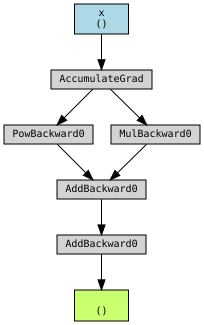

In [ ]:
from torchviz import make_dot

# Assuming 'y' is the output tensor from the previous PyTorch example
# If you ran the previous cell, 'y' should be available.
if 'y' in locals():
  dot = make_dot(y, params={'x': x})
  display(dot)
else:
  print("Please run the previous PyTorch example cell first to generate the 'y' tensor.")